In [2]:
import pandas as pd

submission = pd.read_csv("output/churn_predictions.csv")
test = pd.read_csv("data/test.csv")

In [5]:
submission = pd.read_csv("output/churn_predictions.csv")

submission["RiskLevel"] = pd.cut(
    submission["ChurnProbability"],
    bins=[0,0.2,0.4,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [7]:
submission["MonthlyCharges"] = test["MonthlyCharges"]

Customer PRIORITY SCORE

In [15]:
submission["RetentionPriority"] = (
    submission["ChurnProbability"] * submission["MonthlyCharges"]
)

In [17]:
priority_customers = submission.sort_values(
    "RetentionPriority",
    ascending=False
)

priority_customers.head(10)

,CustomerID,ChurnProbability,ChurnPrediction,RiskLevel,MonthlyCharges,RetentionPriority
18647,9IURSYDCXJ,0.918334,1,High Risk,19.774738,18.159807
38487,2NOX9AV11E,0.899035,1,High Risk,19.858083,17.853117
49124,DDNXBICNC7,0.903949,1,High Risk,19.635700,17.749677
70305,Y3PM416248,0.896360,1,High Risk,19.795683,17.744059
14148,P9DHBQFTD4,0.896820,1,High Risk,19.779090,17.738277
64511,WOH2E5TLSW,0.901406,1,High Risk,19.675138,17.735294
8081,99NR2NWWRM,0.894967,1,High Risk,19.807610,17.727153
63278,I4MR2F4WJM,0.895787,1,High Risk,19.700102,17.647090
44004,4HPSF0TAUL,0.881353,1,High Risk,19.979881,17.609331
30623,Y58B75DWV3,0.880602,1,High Risk,19.956031,17.573327


REVENUE ANALYSIS

In [8]:
# Calculate Revenue at Risk

high_risk = submission[submission["RiskLevel"] == "High Risk"]
revenue_at_risk = high_risk["MonthlyCharges"].sum()
print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 764458.1789229806


Interpretation

The model identified high-risk customers whose combined monthly revenue equals approximately $764K. If these customers churn, the business could lose this revenue.

In [ ]:
# Retain 30% of high-risk customersretention_rate = 0.30
recovered_revenue = revenue_at_risk * retention_rate
print("Recovered Revenue:", recovered_revenue)

Recovered Revenue: 229337.45367689416


Meaning:
If the company successfully retains 30% of high-risk customers, it can recover $229K per month.

In [10]:
# 10% retention discount
discount_rate = 0.10
discount_cost = recovered_revenue * discount_rate
print("Discount Cost:", discount_cost)

Discount Cost: 22933.74536768942


In [11]:
# Calculate Net Profit
net_gain = recovered_revenue - discount_cost
print("Net Gain:", net_gain)

Net Gain: 206403.70830920475


Meaning:
The company would gain ~$206K net revenue from the retention campaign.

In [12]:
summary = pd.DataFrame({
    "Metric":[
        "Revenue at Risk",
        "Recovered Revenue",
        "Discount Cost",
        "Net Gain"
    ],
    "Amount":[
        revenue_at_risk,
        recovered_revenue,
        discount_cost,
        net_gain
    ]
})

summary

,Metric,Amount
0,Revenue at Risk,764458.178923
1,Recovered Revenue,229337.453677
2,Discount Cost,22933.745368
3,Net Gain,206403.708309


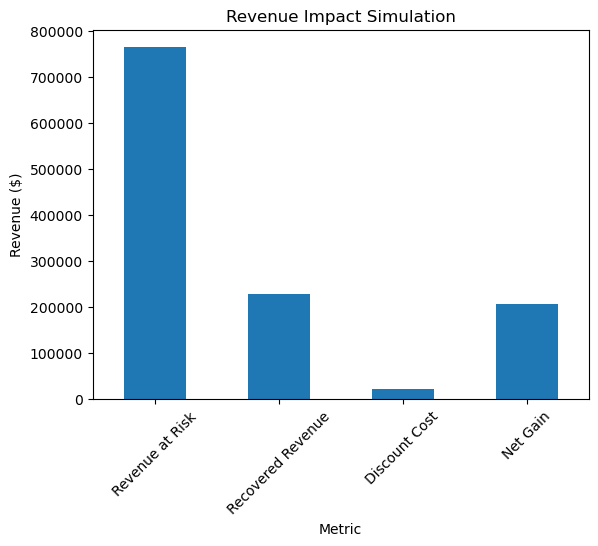

In [14]:
import matplotlib.pyplot as plt 
summary.plot(
    x="Metric",
    y="Amount",
    kind="bar",
    legend=False
)

plt.title("Revenue Impact Simulation")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()